# Prática
Como atividade prática, vou tentar criar uma sétima arquitetura pegando ideias das outras 6 que já foram testadas e ajustar hiperparâmetros para tentar bater uma acurácia melhor dentre as outras.

Testarei também o *transfer learning* com outro modelo pré-treinado (ResNet50, MobileNetV2 ou InterceptionV3) e comparar com a VGG-16.

Depois, rodar um notebook comparando os modelos incluindo o novo modelo na lista de modelos. Se precisar, tentar aplicar *data augmentation* na melhor arquitetura e comparar o antes e depois.

## Etapa 1 - Importação das bibliotecas

In [ ]:
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import drive
import zipfile
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import drive
import zipfile

# Imports do Tensorflow/Keras
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Input, concatenate
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, TensorBoard, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.models import model_from_json
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Para balancear as classes
from sklearn.utils.class_weight import compute_class_weight

print(f"OpenCV: v{cv2.__version__}")
print(f"Tensorflow: v{tf.__version__}")

OpenCV: v5.0.0
Tensorflow: v2.20.0


## Etapa 2 - Acessando a base com fotos de expressões faciais

### Conectando o Drive e acessando os arquivos

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# extrai o material do curso (haarcascade, fotos de teste etc) pra dentro do Colab
# Nesta parte, precisa que voce tenha o arquivo Material.zip no Drive
path = "/content/drive/My Drive/Material.zip"
zip_object = zipfile.ZipFile(file=path, mode="r")
zip_object.extractall("./")
base_imgs = 'Material/fer2013.zip'
zip_object = zipfile.ZipFile(file = base_imgs, mode = "r")
zip_object.extractall("./")
zip_object.close()

In [4]:
# Não faço a minima ideia de que aconteceu, o csv simplesmente nao ficou dento da pasta drive/My Drive/Cursos/Deteccao_Expressoes_Faciais/

dir = 'drive/My Drive/Cursos/Deteccao_Expressoes_Faciais/'
# carrega o csv direto da pasta local (extraída na célula anterior) já que não achei no drive
# Não faço a minima ideia de que aconteceu, o csv simplesmente nao ficou dento da pasta drive/My Drive/Cursos/Deteccao_Expressoes_Faciais/

dir = 'drive/My Drive/Cursos/Deteccao_Expressoes_Faciais/'
data = pd.read_csv('fer2013/fer2013.csv')
data.tail()

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


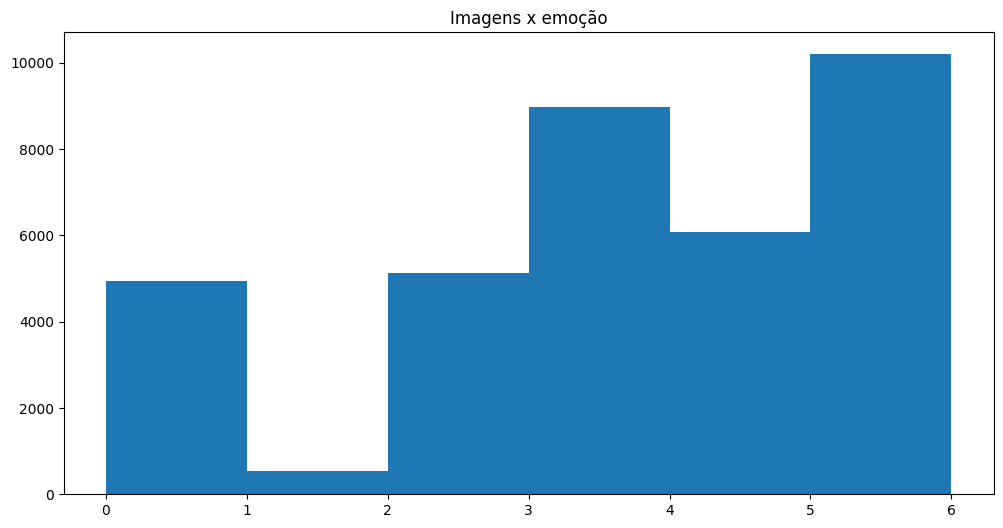

In [ ]:
# histograma pra ver como as emoções estão distribuídas no dataset
# Plota um histograma com a qtd de imgs por classe
plt.figure(figsize=(12,6)) # Tamanho da figura
plt.hist(data['emotion'], bins=6)
plt.title("Imagens x emoção")
plt.show()

# Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

## Etapa 3 - Pré-processamento

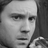

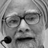

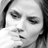

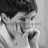

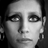

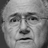

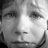

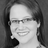

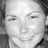

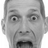

In [ ]:
# a coluna 'pixels' vem como string, com os valores separados por espaço
pixels = data['pixels'].tolist()
largura, altura = 48, 48

faces = []
amostras = 0
for pixel_sequence in pixels:
  face = [int(pixel) for pixel in pixel_sequence.split(' ')]
  face = np.asarray(face).reshape(largura, altura)
  faces.append(face)

  if (amostras < 10):
    cv2_imshow(face)

  amostras = amostras + 1

faces = np.asarray(faces)
faces = np.expand_dims(faces, -1)

def normalizar(x):
    x = x.astype('float32')
    x = x / 255.0
    return x

faces = normalizar(faces)

emocoes = pd.get_dummies(data['emotion']).to_numpy()

In [7]:
# confere quantas imagens no total foram carregadas
print("Número total de imagens no dataset: "+str(len(faces)))

Número total de imagens no dataset: 35887


## Etapa 4 - Dividir em conjuntos para treinamento e validação

In [8]:
# separa 10% dos dados pra teste
# do que sobrou, separa mais 10% pra validação (usada durante o treinamento)
x_train, x_test, y_train, y_test = train_test_split(faces, emocoes, test_size=0.1, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=41)

print("Número de imagens no conjunto de treinamento:", len(x_train))
print("Número de imagens no conjunto de testes:", len(x_test))
print("Número de imagens no conjunto de validação:", len(y_val))

Número de imagens no conjunto de treinamento: 29068
Número de imagens no conjunto de testes: 3589
Número de imagens no conjunto de validação: 3230


Como é possível ver no histograma acima, a classe nojo (2) é a que menos tem imagens no dataset, o que vai causar um desbalanceamento, vou tentar balancear isso.

Para isso, vou usar a função `compute_class_weight`, ela vai balancear o *dataset* atribuindo pesos para as classes, ou seja, quanto menor for a classe (no meu caso, a classe nojo), maior vai ser o peso dela. Depois eu coloco esses pesos no argumento `class_weight` do `.fit()` para o treino.

In [9]:
# confere rapidinho o formato: converte o one-hot de volta pra um id de classe por amostra,
# só pra visualizar (é a mesma conta que o compute_class_weight vai usar embaixo)
np.argmax(y_train, axis=1)

array([3, 5, 0, ..., 3, 3, 3])

In [10]:
# calcula um peso por classe com base em quantas amostras cada uma tem: quanto menor a classe
# (a "Nojo", nesse dataset), maior o peso que ela recebe

# suaviza a diferença entre os pesos com raiz quadrada, senão a classe "Nojo" (a mais rara)
# ficava com um peso tão alto que o modelo passava a "chutar" ela demais, derrubando a precisão
weights_train = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=(np.argmax(y_train, axis=1)))

weights_norm = np.sqrt(weights_train)
# Descobri na hora de rodar o .fit() que ele espera receber algo que se comporte como um dict, precisando de indices
weights_norm = {idx: weights_norm for idx, weights_norm in enumerate(weights_norm)}
weights_norm

{0: np.float64(1.0174948617610577),
 1: np.float64(3.0243401102687244),
 2: np.float64(1.0047990157924487),
 3: np.float64(0.755772961091385),
 4: np.float64(0.915546811795279),
 5: np.float64(1.1333282214719302),
 6: np.float64(0.9083329958924031)}

In [11]:
# salva o conjunto de teste em disco, pra depois recarregar sem refazer o pré-processamento
np.save('mod_xtest', x_test)
np.save('mod_ytest', y_test)

## Etapa 5 - Arquitetura do Modelo

In [12]:
# arquitetura: 4 blocos convolucionais dobrando o número de filtros (32 -> 64 -> 128 -> 256),
# com ativação ELU + BatchNormalization depois de cada Conv2D e Dropout(0.3) no final de cada bloco.
# no final, duas camadas Dense(64) antes da camada de saída com 7 neurônios (uma por emoção)
num_features = 32
num_classes = 7
width, height = 48, 48
batch_size = 64
epochs = 100

model = Sequential()

model.add(Conv2D(num_features, (3, 3), padding = 'same', kernel_initializer="he_normal",
                 input_shape = (width, height, 1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(num_features, (3, 3), padding = "same", kernel_initializer="he_normal",
                 input_shape = (width, height, 1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(2*num_features, (3, 3), padding="same", kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*num_features, (3, 3), padding="same", kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(2*2*num_features, (3, 3), padding="same", kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*num_features, (3, 3), padding="same", kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(2*2*2*num_features, (3, 3), padding="same", kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(2*2*2*num_features, (3, 3), padding="same", kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(2*num_features, kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(2*num_features, kernel_initializer="he_normal"))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(num_classes, kernel_initializer="he_normal"))
model.add(Activation("softmax"))

print(model.summary())

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,328,167 (5.07 MB)

 Trainable params: 1,325,991 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


## Etapa 6 - Data Augmentation

In [ ]:
# o datagen.flow() sozinho, se passado direto pro model.fit(), pode "acabar" no meio do treino
# (o Keras acusa "ran out of data" e trunca a epoch) — por isso empacotamos ele num
# tf.data.Dataset com .repeat(), que garante que os dados nunca se esgotam entre as epochs
datagen = ImageDataGenerator(
      rotation_range=30, # valor de alcance para randomicamente rotacionar a imagem
      shear_range=0.1, # aleatoriamente distorce a imagem (por cisalhamento)
      zoom_range=0.3, # aleatoriamente aplica zoom na imagem
      width_shift_range=0.1, # aleatoriamente alterna as imagens horizontalmente  
      height_shift_range=0.1, # aleatoriamente alterna as imagens verticalmente 
      horizontal_flip=True, # aleatoriamente vira as imagens na horizontal
      vertical_flip=False, # aleatoriamente vira as imagens na vertical
      fill_mode='nearest') # define como vai preencher espaços fora do limite da imagem ('nearest' é o valor padrão)

def data_generator():
    for x, y in datagen.flow(x_train, y_train, batch_size=batch_size):
        yield x, y

train_dataset = tf.data.Dataset.from_generator(
    data_generator,
    output_types=(tf.float32, tf.float32),
    output_shapes=(tf.TensorShape([None, width, height, 1]), tf.TensorShape([None, num_classes]))
).repeat()

print(len(datagen.flow(x_train, y_train, batch_size=batch_size)))

455


## Etapa 7 - Compilando o modelo

In [14]:
# loss padrão pra classificação com várias classes, otimizador Adam
# reduz o learning rate quando a loss de validação para de melhorar
# para o treinamento mais cedo se não houver melhora (evita overfitting/epochs desnecessárias)
# salva automaticamente o melhor modelo (menor val_loss) durante o treino
model.compile(loss=categorical_crossentropy,
              optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-7),
              metrics=['accuracy'])
arquivo_modelo = "modelo_07_expressoes_dataaug.keras" # arquivo do modelo
arquivo_modelo_json = "modelo_07_expressoes_dataaug.json" # arquivo do json, para salvar a arquitetura
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.9, patience=3, verbose=1)
early_stopper = EarlyStopping(monitor='val_loss', min_delta=0, patience=8, verbose=1, mode='auto')
checkpointer = ModelCheckpoint(arquivo_modelo, monitor='val_loss', verbose=1, save_best_only=True)

In [15]:
# salva só a arquitetura do modelo (as camadas) num arquivo json
# os pesos ficam separados, no .keras salvo pelo checkpointer durante o treino
model_json = model.to_json()
with open(arquivo_modelo_json, "w") as json_file:
    json_file.write(model_json)

## Etapa 8 - Treinando o modelo

In [16]:
# usamos fit_generator() ao invés de fit() porque os dados de treinamento vieram de um gerador de dados (Data Generators)
# Passo agora os pesos aqui, agora vou ter os dados balanceados
history = model.fit(train_dataset,
          epochs=epochs,
          verbose=1,
          validation_data=(x_val, y_val),
          validation_steps = len(x_val) // batch_size,
          steps_per_epoch=len(x_train) // batch_size,
          class_weight=weights_norm,
          callbacks=[lr_reducer, early_stopper, checkpointer])

Epoch 1/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1817 - loss: 2.2020
Epoch 1: val_loss improved from None to 1.76384, saving model to modelo_07_expressoes_dataaug.keras

Epoch 1: finished saving model to modelo_07_expressoes_dataaug.keras
454/454 ━━━━━━━━━━━━━━━━━━━━ 50s 52ms/step - accuracy: 0.2004 - loss: 2.0238 - val_accuracy: 0.3022 - val_loss: 1.7638 - learning_rate: 0.0010
Epoch 2/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2472 - loss: 1.8175
Epoch 2: val_loss improved from 1.76384 to 1.70982, saving model to modelo_07_expressoes_dataaug.keras

Epoch 2: finished saving model to modelo_07_expressoes_dataaug.keras
454/454 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.2669 - loss: 1.7847 - val_accuracy: 0.3214 - val_loss: 1.7098 - learning_rate: 0.0010
Epoch 3/100
453/454 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3071 - loss: 1.7057
Epoch 3: val_loss improved from 1.70982 to 1.60788, saving model to modelo_07_expressoes_dataaug.keras

Epo

Gráfico do treinamento

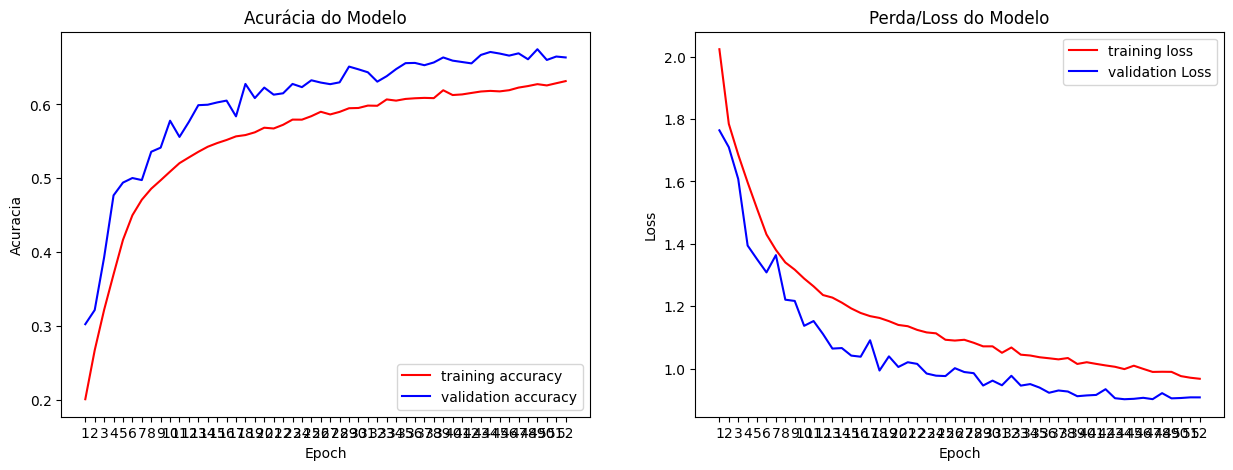

In [17]:
def plota_historico_modelo(historico_modelo):
    fig, axs = plt.subplots(1,2,figsize=(15,5))
    axs[0].plot(range(1,len(historico_modelo.history['accuracy'])+1),
                historico_modelo.history['accuracy'],'r')
    axs[0].plot(range(1,len(historico_modelo.history['val_accuracy'])+1),
                historico_modelo.history['val_accuracy'],'b')
    axs[0].set_title('Acurácia do Modelo')
    axs[0].set_ylabel('Acuracia')
    axs[0].set_xlabel('Epoch')
    # Removido o segundo argumento, pois set_xticks espera uma sequência de rótulos, não um número.
    axs[0].set_xticks(np.arange(1,len(historico_modelo.history['accuracy'])+1))
    axs[0].legend(['training accuracy', 'validation accuracy'], loc='best')

    axs[1].plot(range(1,len(historico_modelo.history['loss'])+1),
                historico_modelo.history['loss'],'r')
    axs[1].plot(range(1,len(historico_modelo.history['val_loss'])+1),
                historico_modelo.history['val_loss'],'b')
    axs[1].set_title('Perda/Loss do Modelo')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_xticks(np.arange(1,len(historico_modelo.history['loss'])+1))
    axs[1].legend(['training loss', 'validation Loss'], loc='best')
    fig.savefig('historico_modelo_mod01.png')
    plt.show()

plota_historico_modelo(history)


Verificação a acurácia

In [18]:
# avalia o modelo já treinado usando o conjunto de teste (imagens que ele nunca viu)
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size)
print("Acurácia: " + str(scores[1]))
print("Perda/Loss: " + str(scores[0]))

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6559 - loss: 0.9202
Acurácia: 0.6558930277824402
Perda/Loss: 0.9201602339744568


Matriz de confusão

In [19]:
# recarrega o conjunto de teste e o modelo (arquitetura + pesos), pra montar a matriz de confusão
# true_y guarda o índice da emoção correta, pred_y guarda o índice que o modelo previu
true_y=[]
pred_y=[]
x = np.load('mod_xtest.npy')
y = np.load('mod_ytest.npy')
json_file = open(arquivo_modelo_json, 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
loaded_model.load_weights(arquivo_modelo)
y_pred= loaded_model.predict(x)
yp = y_pred.tolist()
yt = y.tolist()
count = 0
for i in range(len(y)):
    yy = max(yp[i])
    yyt = max(yt[i])
    pred_y.append(yp[i].index(yy))
    true_y.append(yt[i].index(yyt))
    if(yp[i].index(yy)== yt[i].index(yyt)):
        count+=1
acc = (count/len(y))*100
np.save('truey__mod02', true_y)
np.save('predy__mod02', pred_y)
print("Acurácia no conjunto de testes: "+str(acc)+"%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Acurácia no conjunto de testes: 65.89579269991641%


In [20]:
# monta a matriz comparando o rótulo real x o previsto
from sklearn.metrics import confusion_matrix
y_true = np.load('truey__mod02.npy')
y_pred = np.load('predy__mod02.npy')
cm = confusion_matrix(y_true, y_pred)
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]
titulo='Matriz de Confusão'
print(cm)

[[275  15  35  14  51  17  91]
 [ 11  31   3   0   3   2   2]
 [ 63   5 224  16 113  68  56]
 [ 22   4  10 755  17  23  50]
 [ 53   6  44  21 307   6 151]
 [ 17   1  42  24   4 314  12]
 [ 16   1  26  35  62  12 459]]


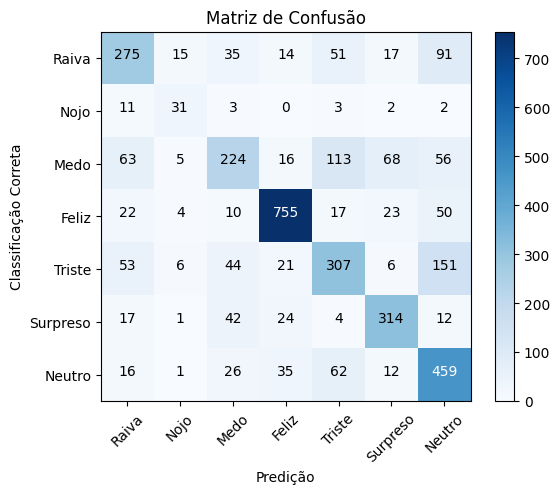

In [21]:
# desenha a matriz de confusão como um "mapa de calor", com o número de acertos/erros em cada célula
import itertools
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(titulo)
plt.colorbar()
tick_marks = np.arange(len(expressoes))
plt.xticks(tick_marks, expressoes, rotation=45)
plt.yticks(tick_marks, expressoes)
fmt = 'd'
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

plt.ylabel('Classificação Correta')
plt.xlabel('Predição')
#plt.savefig(diretorio + 'matriz_confusao_mod07__dataaug.png')
plt.show()

Testando o modelo

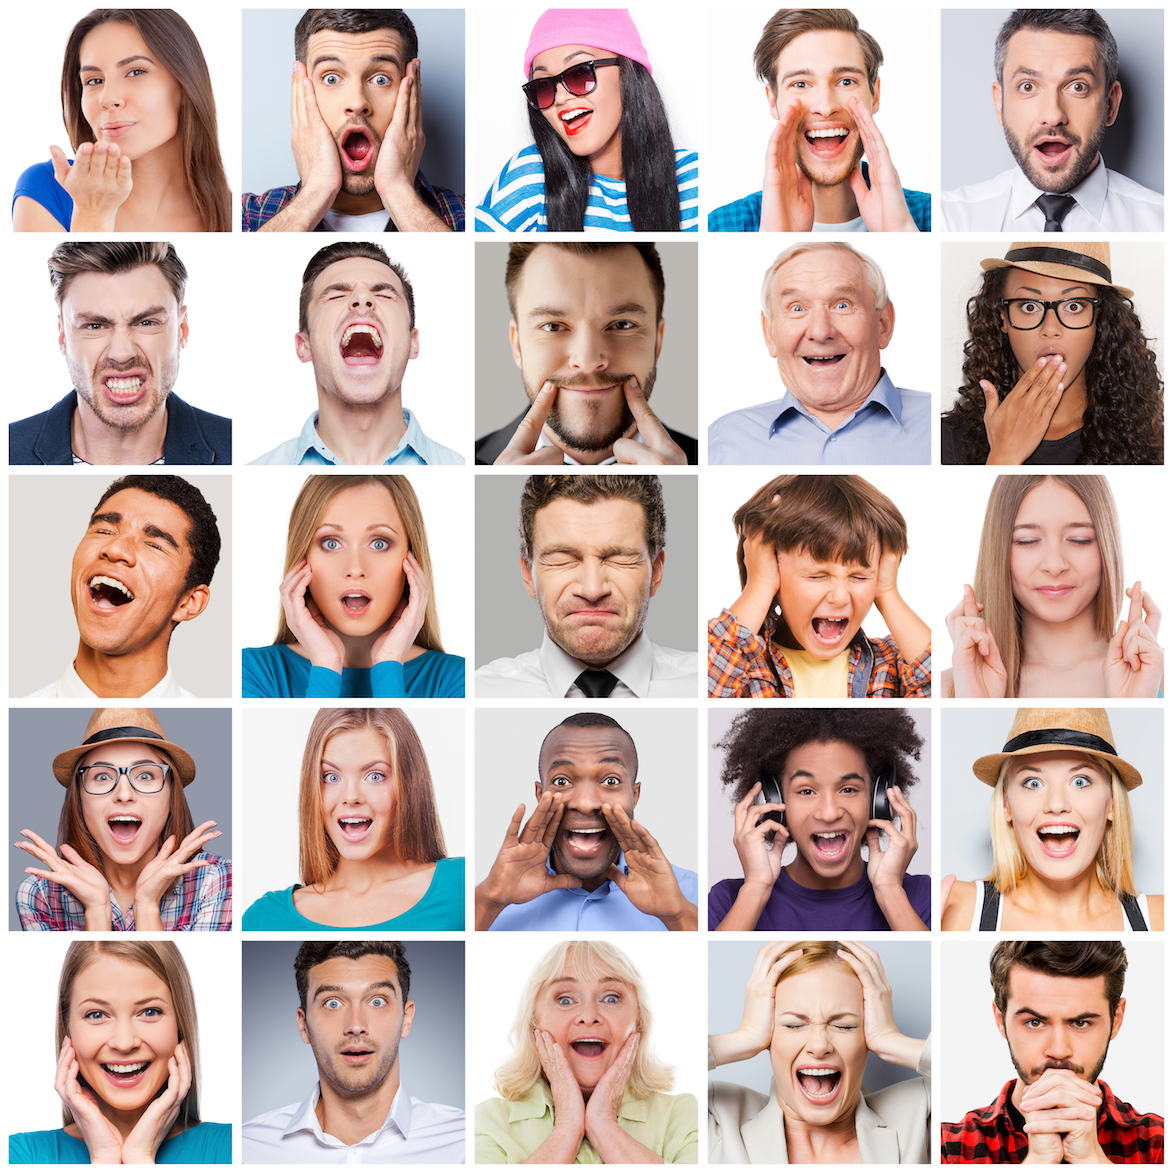

In [22]:
# carrega uma foto de teste, diferente das usadas no treinamento
imagem = cv2.imread("/content/Material/testes/teste03.jpg")
cv2_imshow(imagem)

In [23]:
# recarrega o melhor checkpoint salvo durante o treino, pra rodar o teste rápido abaixo
model = load_model("modelo_07_expressoes_dataaug.keras")
scores = model.evaluate(np.array(x_test), np.array(y_test), batch_size=batch_size)
print("Perda/Loss: " + str(scores[0]))
print("Acurácia: " + str(scores[1]))

57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6590 - loss: 0.9151
Perda/Loss: 0.9151315689086914
Acurácia: 0.6589578986167908


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


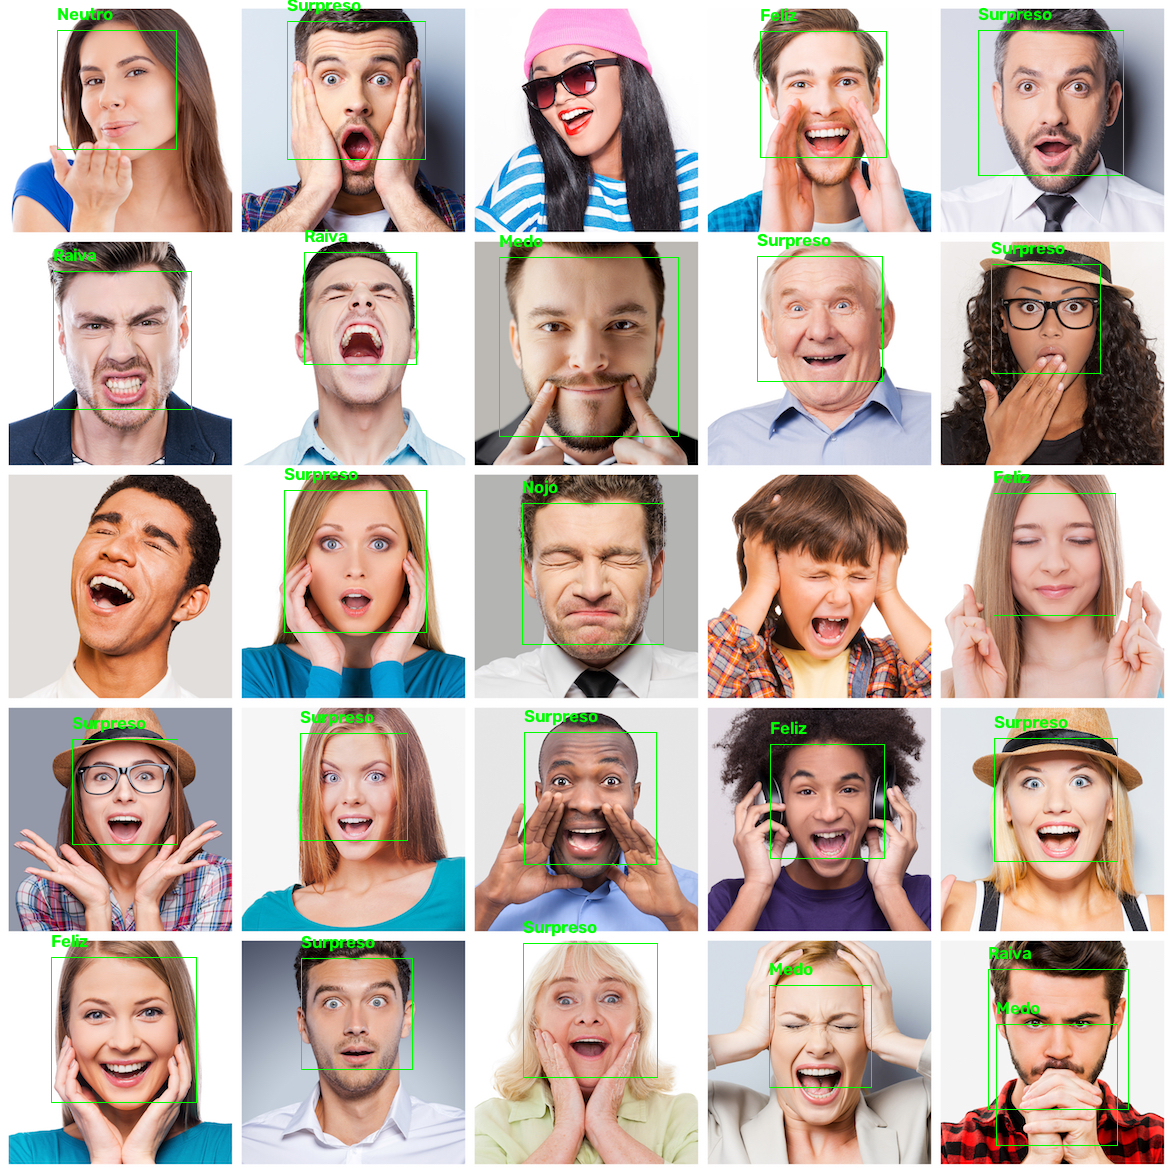

In [24]:
# detecta o(s) rosto(s) na foto de teste e prediz a emoção de cada um, desenhando o resultado
expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]
original = imagem.copy()
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier('/content/Material/haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, 1.1, 3)
for (x, y, w, h) in faces:
    cv2.rectangle(original, (x, y), (x + w, y + h), (0, 255, 0), 1)
    roi_gray = gray[y:y + h, x:x + w]
    roi_gray = roi_gray.astype("float") / 255.0
    cropped_img = np.expand_dims(np.expand_dims(cv2.resize(roi_gray, (48, 48)), -1), 0)
    cv2.normalize(cropped_img, cropped_img, alpha=0, beta=1,
                  norm_type=cv2.NORM_L2, dtype=cv2.CV_32F)
    prediction = model.predict(cropped_img)[0]
    cv2.putText(original, expressoes[int(np.argmax(prediction))], (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
cv2_imshow(original)